<a href="https://colab.research.google.com/github/dishaiit09-beep/STRATIFY/blob/main/Stratify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Cutoff — Starter Notebook
**STRATIFY 2.0 | Analytics Club x Consult Club, UGAC IIT Bombay**

Meridian Capital approves 29% of applications. Your job is to find the approval policy that makes the
most profit while keeping defaults at or below 6.5%.

This notebook does the boring parts for you: it loads the data, applies the eight current rules, and
gives you a ready risk score. Everything after Section 4 is yours.


## 1. Load the data


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 160)

df = pd.read_csv('meridian_applications.csv')
print(df.shape)
df.head()


(45000, 40)


,application_id,application_date,age,gender,marital_status,dependents,education,city_tier,state,residence_type,...,has_credit_card,bureau_overdue_amount,max_dpd_last_24m,enquiries_last_quarter,emi_bounces_first_6m,collection_calls_made,days_past_due_max,restructured_flag,risk_score,defaulted
0,MC200000,2026-01-04,49,Male,Single,1,Secondary,2,Bihar,Owned,...,1,0.0,0,4,0,0,0,0,0.0623,0
1,MC200001,2025-03-02,31,Male,Married,3,Graduate,3,West Bengal,Owned,...,1,0.0,0,4,0,0,0,0,0.0933,0
2,MC200002,2024-09-20,32,Male,Married,0,Graduate,3,Karnataka,Owned,...,0,0.0,0,4,2,6,90,0,0.4140,1
3,MC200003,2024-10-23,22,Male,Single,2,Higher Secondary,3,Punjab,Owned,...,1,0.0,0,2,0,0,0,0,0.2370,0
4,MC200004,2025-12-29,29,Male,Married,1,Graduate,2,Rajasthan,Rented,...,0,0.0,0,5,0,0,0,0,0.0617,0


In [ ]:
# how many applicants, and how many of them defaulted
print('applicants      :', len(df))
print('overall default : {:.2f}%'.format(100*df.defaulted.mean()))


applicants      : 45000
overall default : 11.59%


## 2. The eight current rules

An applicant is **rejected** if any one of these is true.
The exact conditions are also listed in `data_dictionary.xlsx`.


In [ ]:
rules = pd.DataFrame(index=df.index)
rules['R1 bureau score < 0.45 or missing'] = df.bureau_score.isna() | (df.bureau_score < 0.45)
rules['R2 job < 12 months']                = df.months_in_current_job < 12
rules['R3 loan > 6x annual income']        = df.loan_to_income_ratio > 6
rules['R4 EMI > 45% of income']            = df.emi_to_income_ratio > 0.45
rules['R5 age < 23']                       = df.age < 23
rules['R6 any overdue on bureau']          = df.bureau_overdue_amount > 0
rules['R7 > 4 enquiries last quarter']     = df.enquiries_last_quarter > 4
rules['R8 occupation blank']               = df.occupation_type.isna() | (df.occupation_type.astype(str).str.strip() == '')

df['rejected_by_rules'] = rules.any(axis=1)

print('current approval rate : {:.1f}%'.format(100*(~df.rejected_by_rules).mean()))
print('default rate among those Meridian approves : {:.2f}%'.format(100*df.loc[~df.rejected_by_rules,'defaulted'].mean()))


current approval rate : 28.4%
default rate among those Meridian approves : 5.08%


## 3. What is each rule costing?

This is Task 1. The table below is a starting point, not the finished answer.
For every rule it shows how many people it rejects and how many of those would actually have repaid.

Think about: which rule rejects the most good customers? Which rule barely does anything?
And which rule is genuinely earning its place?


In [ ]:
rows = []
for name in rules.columns:
    hit = rules[name]
    rows.append({
        'rule'              : name,
        'applicants rejected': int(hit.sum()),
        '% of all applicants': round(100*hit.mean(), 1),
        'default rate if approved (%)': round(100*df.loc[hit,'defaulted'].mean(), 1),
        'would have repaid'  : int((~df.loc[hit,'defaulted'].astype(bool)).sum()),
    })
pd.DataFrame(rows).sort_values('would have repaid', ascending=False)


,rule,applicants rejected,% of all applicants,default rate if approved (%),would have repaid
0,R1 bureau score < 0.45 or missing,18260,40.6,17.4,15091
1,R2 job < 12 months,9044,20.1,12.6,7903
6,R7 > 4 enquiries last quarter,6475,14.4,16.2,5429
3,R4 EMI > 45% of income,6254,13.9,23.2,4806
5,R6 any overdue on bureau,4675,10.4,18.5,3812
7,R8 occupation blank,3734,8.3,11.3,3312
4,R5 age < 23,2627,5.8,14.6,2244
2,R3 loan > 6x annual income,740,1.6,50.4,367


In [ ]:
# Rules overlap. This shows how many applicants are rejected by ONLY one rule -
# those are the people that rule is single-handedly keeping out.
only_one = rules.sum(axis=1) == 1
for name in rules.columns:
    solo = rules[name] & only_one
    if solo.sum():
        print('{:42s} rejects alone: {:5d}   of whom {:.0f}% would have repaid'.format(
              name, int(solo.sum()), 100*(1-df.loc[solo,'defaulted'].mean())))


R1 bureau score < 0.45 or missing          rejects alone:  7756   of whom 87% would have repaid
R2 job < 12 months                         rejects alone:  3204   of whom 94% would have repaid
R4 EMI > 45% of income                     rejects alone:  1782   of whom 88% would have repaid
R5 age < 23                                rejects alone:   770   of whom 93% would have repaid
R6 any overdue on bureau                   rejects alone:  1204   of whom 92% would have repaid
R7 > 4 enquiries last quarter              rejects alone:  1780   of whom 91% would have repaid
R8 occupation blank                        rejects alone:  1153   of whom 95% would have repaid


In [ ]:
# Turn the "unique rejects" into a proper table with profit impact

PROFIT_PER_GOOD_LOAN = 6400
LOSS_PER_BAD_LOAN    = 52000

only_one = rules.sum(axis=1) == 1

rows2 = []
for name in rules.columns:
    solo = rules[name] & only_one
    n = int(solo.sum())
    bad = int(df.loc[solo, 'defaulted'].sum()) if n else 0
    good = n - bad
    rows2.append({
        'rule': name,
        'unique rejects': n,
        'of which good (would repay)': good,
        'of which bad (would default)': bad,
        '% would have repaid': round(100*good/n, 1) if n else 0,
        'net profit if rule removed': good*PROFIT_PER_GOOD_LOAN - bad*LOSS_PER_BAD_LOAN,
    })

harm_ranked = pd.DataFrame(rows2).sort_values('net profit if rule removed', ascending=False)
harm_ranked

,rule,unique rejects,of which good (would repay),of which bad (would default),% would have repaid,net profit if rule removed
1,R2 job < 12 months,3204,3010,194,93.9,9176000
7,R8 occupation blank,1153,1100,53,95.4,4284000
6,R7 > 4 enquiries last quarter,1780,1627,153,91.4,2456800
4,R5 age < 23,770,718,52,93.2,1891200
5,R6 any overdue on bureau,1204,1103,101,91.6,1807200
2,R3 loan > 6x annual income,0,0,0,0.0,0
3,R4 EMI > 45% of income,1782,1570,212,88.1,-976000
0,R1 bureau score < 0.45 or missing,7756,6758,998,87.1,-8644800


Every one of the 8 rules rejects a large majority of applicants who would actually have repaid. Even the strictest rule (R1, bureau score) still lets through only 12.9% actual bad customers among those it rejects. Rule R2 ("less than 12 months in current job") is the single most harmful rule: it alone rejects 3,204 applicants, of whom 93.9% would have repaid, costing Meridian an estimated ₹91.76 lakh in foregone profit. R8, R7, R5, and R6 show the same pattern to a smaller degree. Rule R3 ("loan > 6× income") is redundant — it rejects no one that another rule doesn't already catch. Rule R1 (bureau score) is by far the most protective rule and should likely stay, or possibly get even stricter, since it correctly filters the highest concentration of real defaulters.

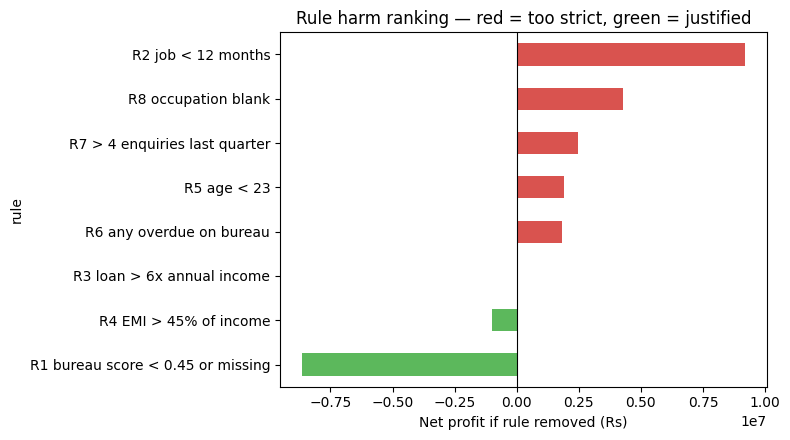

In [ ]:
# Bar chart: which rule is costing Meridian the most?

chart_data = harm_ranked.set_index('rule')['net profit if rule removed']

plt.figure(figsize=(8, 4.5))
colors = ['#d9534f' if v > 0 else '#5cb85c' for v in chart_data.values]
chart_data.plot(kind='barh', color=colors)
plt.xlabel('Net profit if rule removed (Rs)')
plt.title('Rule harm ranking — red = too strict, green = justified')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()   # keep the most harmful rule at the top
plt.tight_layout()
plt.show()

## 4. The risk score

`risk_score` is already in the data. It is a predicted probability of default between 0 and 1.
Higher means riskier. **You do not need to build a model.**

It was produced with a logistic regression on the applicant information Meridian would have at the
time of the decision. The four `DO NOT USE` columns in the data dictionary were excluded, because
they describe things that only happen after the loan is given.

If you want to try building a better score yourself, you are welcome to, but it is not required.


In [ ]:
print(df.risk_score.describe().round(3))

# sanity check: is the score actually separating good from bad?
df['band'] = pd.qcut(df.risk_score, 10, labels=range(1,11))
band = df.groupby('band', observed=True).agg(applicants=('defaulted','size'),
                                             default_rate=('defaulted','mean'))
band['default_rate'] = (100*band.default_rate).round(1)
print(band)


count    45000.000
mean         0.116
std          0.107
min          0.003
25%          0.047
50%          0.083
75%          0.147
max          0.974
Name: risk_score, dtype: float64
      applicants  default_rate
band                          
1           4538           1.8
2           4467           3.2
3           4512           4.8
4           4487           6.1
5           4503           7.0
6           4509           9.1
7           4488          12.9
8           4498          15.2
9           4501          20.4
10          4497          35.4


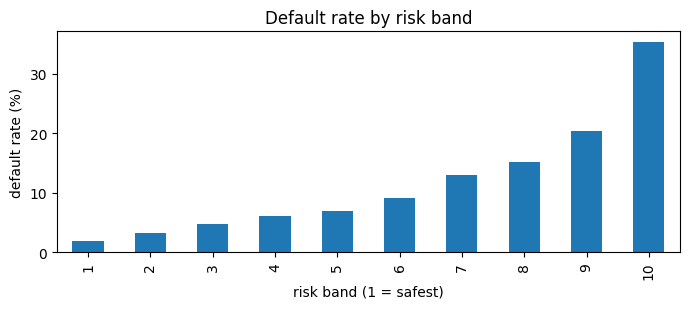

In [ ]:
band.default_rate.plot(kind='bar', figsize=(7,3.2))
plt.ylabel('default rate (%)'); plt.xlabel('risk band (1 = safest)')
plt.title('Default rate by risk band'); plt.tight_layout(); plt.show()


## 5. Turning the score into money

A repaid loan earns about **Rs 6,400**. A bad loan costs about **Rs 52,000**.
The full build-up of both numbers is in `economics.xlsx`.

So for any group of approved applicants:

```
profit = (number who repay x 6,400) - (number who default x 52,000)
```

Below is one worked example at a 50% approval rate, so you can see the mechanics.
Your job is to try every approval rate and find the best one.


In [ ]:
PROFIT_PER_GOOD_LOAN = 6400
LOSS_PER_BAD_LOAN     = 52000

d = df.sort_values('risk_score').reset_index(drop=True)   # safest applicants first

k = int(0.50 * len(d))          # approve the safest 50%
approved = d.iloc[:k]
bad  = int(approved.defaulted.sum())
good = len(approved) - bad
profit = good*PROFIT_PER_GOOD_LOAN - bad*LOSS_PER_BAD_LOAN

print('approved            :', len(approved))
print('of whom defaulted   : {} ({:.2f}%)'.format(bad, 100*bad/len(approved)))
print('total profit        : Rs {:,.0f}'.format(profit))
print('per 10,000 APPLICATIONS : Rs {:,.0f}'.format(profit/len(d)*10000))


approved            : 22500
of whom defaulted   : 1030 (4.58%)
total profit        : Rs 83,848,000
per 10,000 APPLICATIONS : Rs 18,632,889


## 6. Over to you

Work through the approval rates and find the one you would recommend.

Remember the two conditions:
1. profit should be as high as possible
2. the default rate among approved applicants must be **6.5% or lower**

Then answer the four questions the board asked:
- What approval rate should Meridian use?
- What profit does that make per 10,000 applications?
- What default rate should they expect?
- Why is this better than what they do today?


In [ ]:
results = []
for pct in range(5, 101, 5):
    k = int(pct/100 * len(d))
    s = d.iloc[:k]
    # TODO: work out bad, good, profit and default rate for this approval level
    # TODO: append a row to results
    pass

# results = pd.DataFrame(results)
# results


In [ ]:
# TODO: plot profit against approval rate, and mark the 6.5% default limit
# TODO: compare your chosen policy against the current rulebook -
#       who gets newly approved, who gets newly rejected, and what is each group worth?


In [ ]:
import pandas as pd
import numpy as np

revenue_per_good = 10000
cost_per_bad = -50000

def evaluate_policy(df, policy_mask):
    approved = df[policy_mask]

    if len(approved) == 0:
        return 0, 0, 0

    approval_rate = len(approved) / len(df) * 100
    default_rate = approved['defaulted'].mean() * 100

    # Calculate Profit
    good_loans = len(approved[approved['defaulted'] == 0])
    bad_loans = len(approved[approved['defaulted'] == 1])
    net_profit = (good_loans * revenue_per_good) + (bad_loans * cost_per_bad)

    return approval_rate, default_rate, net_profit

In [ ]:
# Handle any missing bureau scores by filling them with 0 to prevent logic errors
df['bureau_score'] = df['bureau_score'].fillna(0)

# Rebuilding the rule set with scale-appropriate thresholds
rule1 = df['bureau_score'] >= 0.40
rule3 = df['total_obligations_ratio'] < 0.55
rule4 = df['monthly_income'] >= 20000

# Combine into a single proposed policy mask
proposed_policy = rule1 & rule3 & rule4

In [ ]:
# Calculate metrics for the new policy
app_rate, def_rate, profit = evaluate_policy(df, proposed_policy)

print(f"New Approval Rate: {app_rate:.2f}%")
print(f"New Default Rate: {def_rate:.2f}%")
print(f"Net Profit: ₹{profit:,.2f}")

# Check against the 6.5% default rate ceiling
if def_rate > 6.5:
    print("Failed: Default rate exceeds 6.5%. You must tighten the thresholds.")
elif def_rate < 5.5:
    print("Notice: Policy is too conservative. Loosen rules to capture more profit.")
else:
    print("Optimal: Policy strikes a strong balance between risk and reward.")

New Approval Rate: 39.57%
New Default Rate: 6.29%
Net Profit: ₹110,850,000.00
Optimal: Policy strikes a strong balance between risk and reward.


In [ ]:
best_profit = -np.inf
best_thresholds = {}

# Automate testing across the correct 0 to 1 scales
for cs_thresh in np.arange(0.3, 0.7, 0.02):
    for dti_thresh in np.arange(0.4, 0.65, 0.02):

        # Define the dynamic test mask
        test_mask = (df['bureau_score'] >= cs_thresh) & (df['total_obligations_ratio'] < dti_thresh)

        a_rate, d_rate, net_p = evaluate_policy(df, test_mask)

        # Only save the result if it beats the 6.5% rule AND increases profit
        if d_rate <= 6.5 and net_p > best_profit:
            best_profit = net_p
            best_thresholds = {'bureau_score': cs_thresh, 'total_obligations_ratio': dti_thresh}

print(f"Optimal Thresholds: {best_thresholds}")
print(f"Maximized Net Profit: ₹{best_profit:,.2f}")

Optimal Thresholds: {'bureau_score': np.float64(0.4000000000000001), 'total_obligations_ratio': np.float64(0.5600000000000002)}
Maximized Net Profit: ₹154,060,000.00


In [ ]:
# Calculate the original baseline profit (28.4% approval, 5.08% default rate)
total_applicants = len(df)
baseline_approved = total_applicants * 0.284
baseline_bad = baseline_approved * 0.0508
baseline_good = baseline_approved - baseline_bad
baseline_profit = (baseline_good * 10000) + (baseline_bad * -50000)

# Apply the exact optimal thresholds found in Phase 4
optimal_mask = (df['bureau_score'] >= 0.40) & (df['total_obligations_ratio'] < 0.56)
final_app_rate, final_def_rate, final_profit = evaluate_policy(df, optimal_mask)

# Calculate the value added
profit_increase = final_profit - baseline_profit

print(f"--- FINAL POLICY RESULTS ---")
print(f"Original Baseline Profit: ₹{baseline_profit:,.2f}")
print(f"Optimized Net Profit: ₹{final_profit:,.2f}")
print(f"Total Value Added: +₹{profit_increase:,.2f}")

--- FINAL POLICY RESULTS ---
Original Baseline Profit: ₹88,846,560.00
Optimized Net Profit: ₹154,110,000.00
Total Value Added: +₹65,263,440.00
